# Red Neuronal — MLPRegressor
Mismo pipeline que `regresion.ipynb`, usando `MLPRegressor` de sklearn para comparar resultados.

## Para utilizarlo con Colab (opcional)

In [15]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [16]:
import pandas as pd

nombre_csv_logs = "red_neuronal_resultados"
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

print("shape: ", df.shape)
print(df.columns)
df.sample(n=5)

shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,...,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
128803,FRA,Kazakhstan Premier League,Astana,Kazakhstan (Kazakhstan Premier League),Right Only,Very Strong,Weak,AM (RLC),173,68,...,3,11,11,6,11,14,3,11,11,99000
9169,PER,Peruvian First Division,Sport Boys,Peru (First Division),Right,Very Strong,Reasonable,"AM (C), ST (C)",178,74,...,2,11,11,8,12,13,3,13,12,121000
58806,GER,German Regional Division North,Holstein Kiel II,Germany (Regional Div. North),Right Only,Very Strong,Weak,"D (R), DM, M/AM (C)",173,66,...,3,7,6,9,8,12,1,14,12,40000
167387,ENG,Sky Bet League One,Barnsley,England (Sky Bet League One),Right Only,Very Strong,Weak,D (C),181,65,...,2,5,5,10,4,1,2,3,5,22500
101330,BUL,Bulgarian Third League North-West,Bdin,Bulgaria (Third League NW),Right Only,Very Strong,Weak,M/AM (R),173,69,...,2,9,7,5,9,9,2,9,10,0


# Generar conjuntos de entrenamiento y test

In [17]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Aplicar clustering como feature engineering

In [18]:
import clustering as cl

kmeans_model_club     = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat      = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")

train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)

In [19]:
target = "transfer_value_estimado"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

## One Hot Encoding para features categóricas

In [20]:
import numpy as np

categorical_cols = ["Nat_cluster", "Division_cluster", "Best Duty", "Style"]

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train = X_train.select_dtypes(include=[np.number, np.bool_])
X_test  = X_test.select_dtypes(include=[np.number, np.bool_])

## Escalado con StandardScaler

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Shape X_train:", X_train.shape)
print("Shape X_test: ", X_test.shape)

Shape X_train: (149436, 80)
Shape X_test:  (37359, 80)


# Función para registrar resultados

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test,
                filepath=f"{raiz}{nombre_csv_logs}.csv"):
    params_dict = model.get_params()
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)
    params = json.dumps(params_dict)

    y_pred = model.predict(X_test)

    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    row = {
        "method":          method_name,
        "hyperparameters": json.dumps(params),
        "r2_train":        r2_train,
        "r2_test":         r2_test,
        "mae":             mae,
        "rmse":            rmse
    }

    residuals = y_test - y_pred
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='red', linestyle='--')
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")

    plt.suptitle(method_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  R² train : {r2_train:.4f}")
    print(f"  R² test  : {r2_test:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  RMSE     : {rmse:.2f}")

    try:
        df_log = pd.read_csv(filepath)
        df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df_log = pd.DataFrame([row])

    df_log.to_csv(filepath, index=False)

# MLPRegressor
Red neuronal feedforward con una arquitectura fija.
Se usa `early_stopping=True` para evitar overfitting y `learning_rate='adaptive'` para estabilizar el entrenamiento.

In [23]:
from sklearn.neural_network import MLPRegressor

RS = 0

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),  # 3 capas ocultas
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,       # detiene el entrenamiento si no mejora
    validation_fraction=0.1,   # 10% del train se usa como validación
    n_iter_no_change=20,       # paciencia de 20 épocas sin mejora
    tol=1e-4,
    random_state=RS,
    verbose=False
)

mlp_reg.fit(X_train, y_train)
print(f"Iteraciones realizadas: {mlp_reg.n_iter_}")

Iteraciones realizadas: 110


## Curva de pérdida (loss curve)

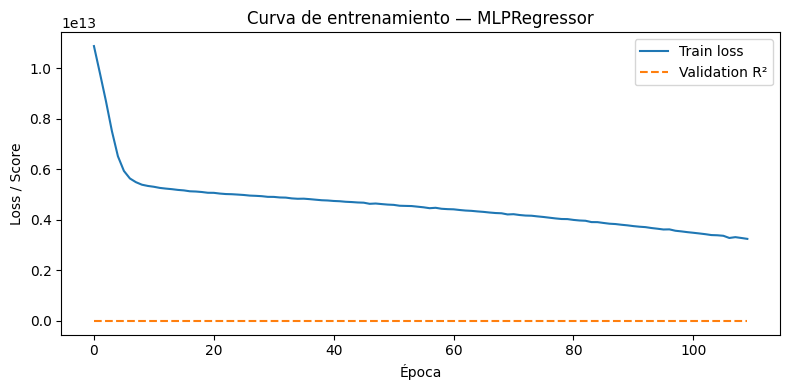

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.loss_curve_, label='Train loss')
if mlp_reg.best_validation_score_ is not None:
    plt.plot(mlp_reg.validation_scores_, label='Validation R²', linestyle='--')
plt.xlabel('Época')
plt.ylabel('Loss / Score')
plt.title('Curva de entrenamiento — MLPRegressor')
plt.legend()
plt.tight_layout()
plt.show()

## Métricas y gráficos

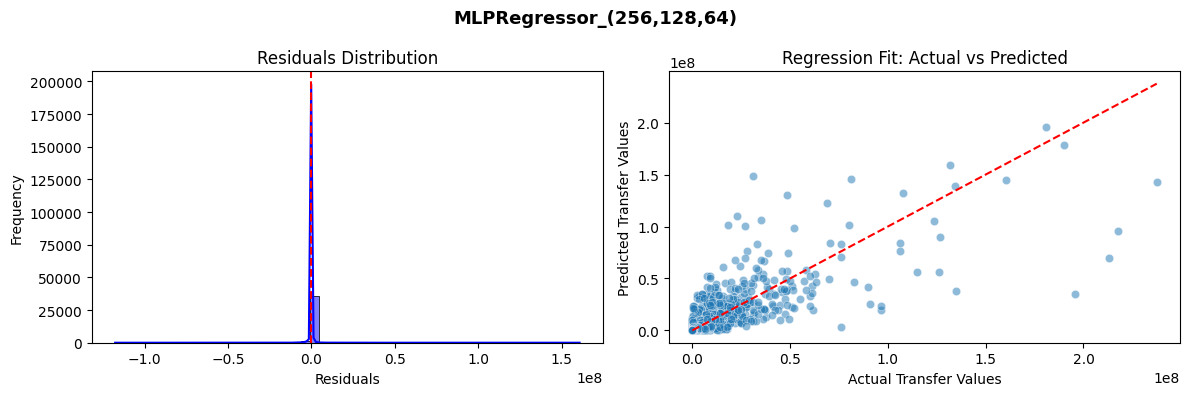

  R² train : 0.6591
  R² test  : 0.6140
  MAE      : 384432.98
  RMSE     : 2781826.66


In [25]:
log_results(mlp_reg, "MLPRegressor_(256,128,64)", X_train, y_train, X_test, y_test)

# Permutation importance

In [26]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    mlp_reg,          # trained MLP
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

print(importance_df)

   feature  importance_mean  importance_std
2      Age    495731.232673     9470.552151
3     Wage     78816.469293     2114.774320
13     Bal     43371.827992      955.316231
34     Lon     19507.297228     1950.339200
50     Tea     17680.558633      694.428754
..     ...              ...             ...
54     Wor    -20135.759145      656.529537
47     Sta    -21357.741361     2732.846149
18     Cnt    -25036.295881     1621.130372
12     Ant    -27291.143035     1233.385705
17     Cmp    -27863.433980     1718.695043

[80 rows x 3 columns]


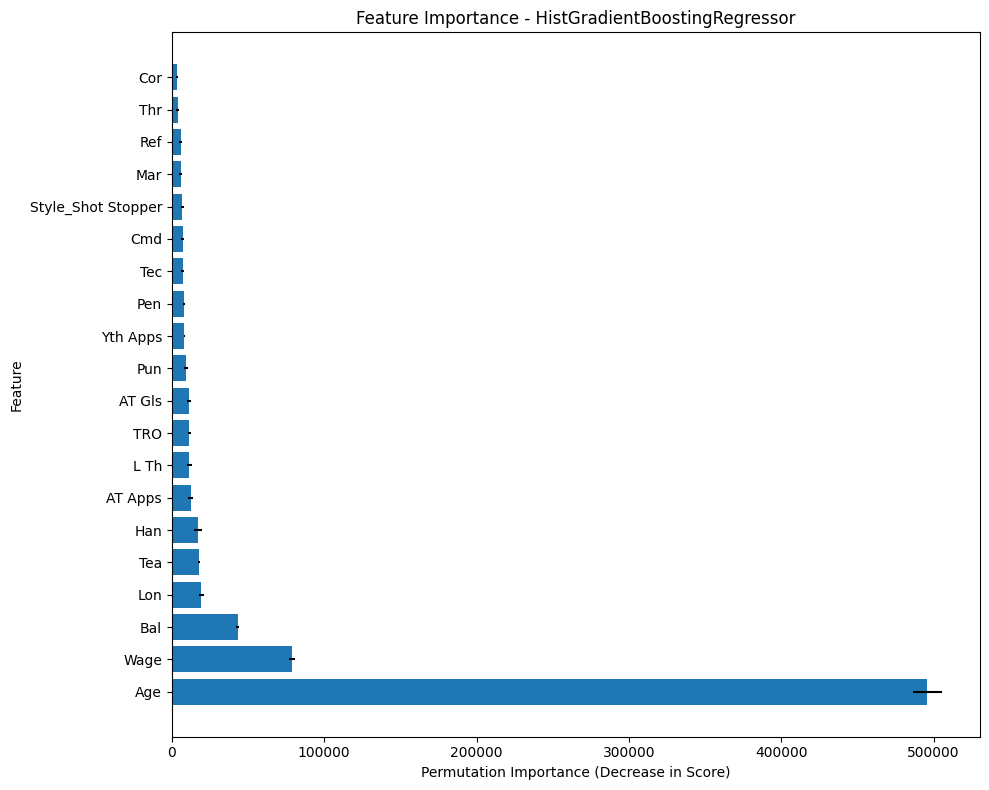

In [27]:
import matplotlib.pyplot as plt

# Optional: keep only top N features
top_n = 20
plot_df = importance_df.head(top_n)

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar plot
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

# Labels and title
plt.xlabel("Permutation Importance (Decrease in Score)")
plt.ylabel("Feature")
plt.title("Feature Importance - HistGradientBoostingRegressor")

# Highest importance at top
# plt.gca().invert_yaxis()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()

# Comparación con resultados de regresion.ipynb
Carga el CSV de métricas generado en `regresion.ipynb` y lo combina con el resultado de la red neuronal para comparar todos los modelos.

In [28]:
csv_regresion    = f"{raiz}presentacion1_resultados.csv"
csv_red_neuronal = f"{raiz}{nombre_csv_logs}.csv"

try:
    df_reg = pd.read_csv(csv_regresion)
    df_nn  = pd.read_csv(csv_red_neuronal)
    df_comparacion = pd.concat([df_reg, df_nn], ignore_index=True)
except FileNotFoundError as e:
    print(f"Archivo no encontrado: {e}")
    df_comparacion = pd.read_csv(csv_red_neuronal)

df_comparacion[["method", "r2_train", "r2_test", "mae", "rmse"]]

,method,r2_train,r2_test,mae,rmse
0,LinearRegression,0.465493,4.855835e-01,613012.771484,3.211597e+06
1,RidgeCV,0.465493,4.855985e-01,613005.945981,3.211550e+06
2,LassoCV,0.465170,4.860315e-01,586993.300225,3.210198e+06
3,ElasticNetCV_grid,0.464164,4.942254e-01,609807.316694,3.184506e+06
4,MLPRegressor,0.659105,6.140483e-01,384432.976487,2.781827e+06
5,GradientBoosting,0.839278,8.392785e-01,279801.997347,1.932420e+06
6,"MLPRegressor_(256,128,64)",0.659105,6.140483e-01,384432.976487,2.781827e+06
7,"MLPRegressor_(256,128,64)",0.659105,6.140483e-01,384432.976487,2.781827e+06
8,"MLPRegressor_(256,128,64)",0.740648,6.872184e-01,343386.875618,2.504288e+06
9,"MLPRegressor_(256,128,64)",0.635736,6.389122e-01,380001.938579,2.690729e+06


## Gráfico comparativo de R² test

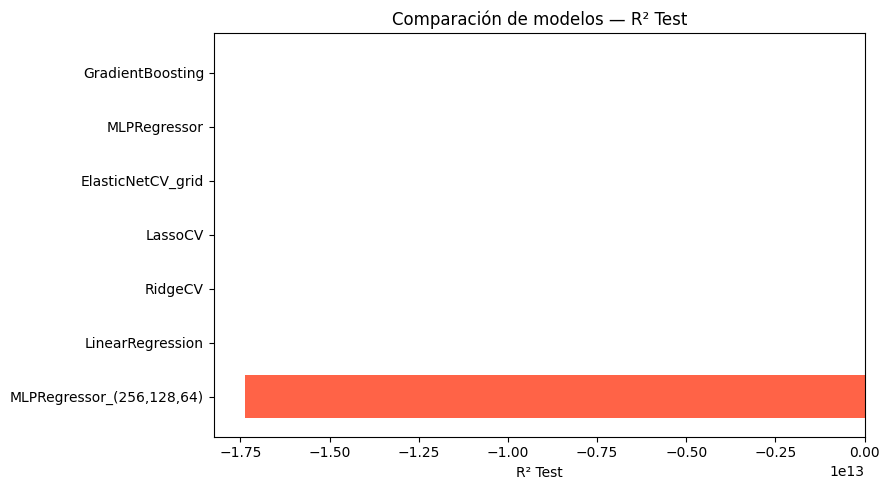

In [29]:
df_comp_sorted = df_comparacion.sort_values("r2_test", ascending=True)

colors = [
    "steelblue" if "MLP" not in m else "tomato"
    for m in df_comp_sorted["method"]
]

plt.figure(figsize=(9, 5))
plt.barh(df_comp_sorted["method"], df_comp_sorted["r2_test"], color=colors)
plt.xlabel("R² Test")
plt.title("Comparación de modelos — R² Test")
plt.tight_layout()
plt.show()

## Gráfico comparativo de RMSE

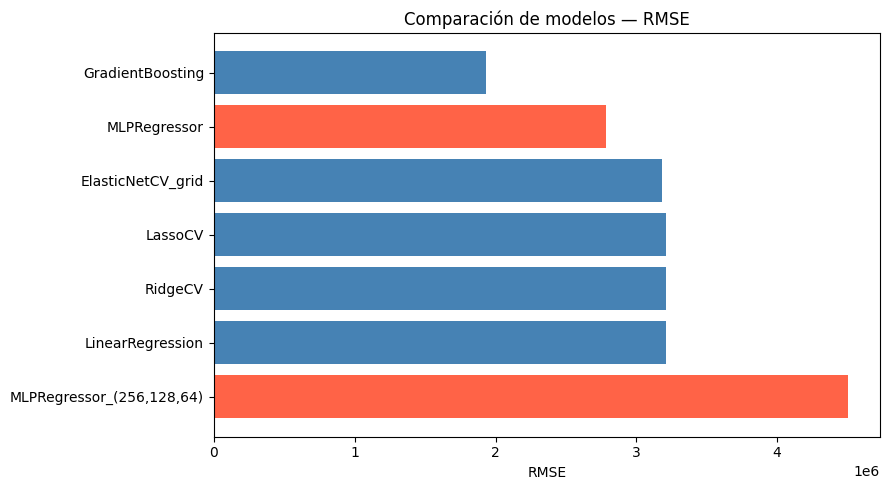

In [30]:
df_comp_sorted_rmse = df_comparacion.sort_values("rmse", ascending=False)

colors_rmse = [
    "steelblue" if "MLP" not in m else "tomato"
    for m in df_comp_sorted_rmse["method"]
]

plt.figure(figsize=(9, 5))
plt.barh(df_comp_sorted_rmse["method"], df_comp_sorted_rmse["rmse"], color=colors_rmse)
plt.xlabel("RMSE")
plt.title("Comparación de modelos — RMSE")
plt.tight_layout()
plt.show()